# Часть 1 - Анализ дифференциальной экспрессии (DESeq2)

## Часть 1. DESeq2 анализ

### 0. Постановка задачи и характеристика данных

Исследование направлено на выявление генов, дифференциально экспрессированных между двумя группами пациентов с раком легкого, получавших терапию ингибиторами иммунных контрольных точек (ICI):

- R (responders) — пациенты с подтвержденным ответом на терапию;
- NR (non-responders) — пациенты, не ответившие на терапию.

Входные данные представлены двумя файлами:

- `raw_counts_ici_samples.tsv` — матрица сырых количеств прочтений;
- `meta_responses.tsv` — метаданные с указанием принадлежности каждого образца к группе R или NR.

Анализ выполняется с использованием DESeq2. Статистически значимыми считаются гены с FDR (padj) < 0,05. Группа NR выбрана в качестве референсной, поэтому положительный log2FC соответствует повышению экспрессии у R, отрицательный — у NR.

### 1. PCA-анализ

Для оценки структуры данных и выявления потенциальных выбросов был выполнен PCA-анализ на DESeq2-нормализованных RNA-seq данных. Первые две главные компоненты объясняют 44,9% общей дисперсии (PC1 — 37,4%, PC2 — 7,4%).

Группы responders (R) и non-responders (NR) частично перекрываются, полного разделения не наблюдается, что ожидаемо для гетерогенных опухолевых данных. Большинство образцов формируют общий кластер без выраженных технических артефактов.

На PCA были выявлены три потенциальных выброса:

| Образец | Группа |
|---------|--------|
| Luc_65_S30_R1_001 | NR |
| LuC_56_S19_R1_001 | NR |
| Luc-1_S10_R1_001 | NR |

Данные образцы существенно удалены от основной группы по PC1 и могут быть связаны как с техническими особенностями, так и с редкой биологической вариацией. Для уменьшения их влияния на результаты дифференциального анализа они были исключены из дальнейшего анализа. После фильтрации осталось 54 образца (15 R и 39 NR).

Явных признаков batch-effect на PCA-графике не наблюдается, однако из-за отсутствия соответствующих метаданных полностью исключить его наличие невозможно.

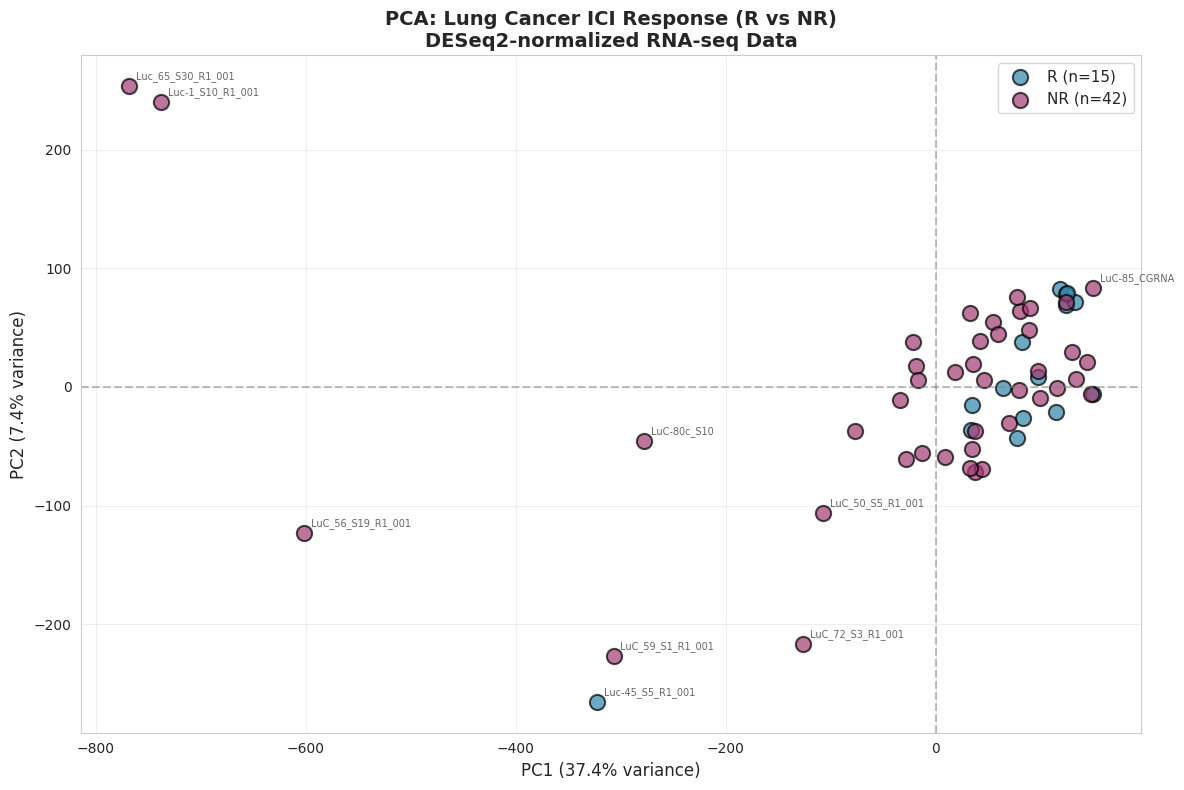

### 2. Clustermap образцов

Для оценки сходства между образцами была построена кластеризованная тепловая карта (clustermap) корреляционной матрицы Пирсона по топ-500 наиболее вариабельным генам после нормализации.

На тепловой карте наблюдается частичное разделение образцов responders (R) и non-responders (NR), однако полного разделения групп не происходит. Образцы формируют несколько смешанных кластеров, что согласуется с результатами PCA и отражает высокую биологическую гетерогенность опухолей.

Средние внутригрупповые корреляции (R-R и NR-NR) несколько выше межгрупповой корреляции (R-NR), что указывает на наличие различий в транскриптомных профилях между группами. При этом выраженных изолированных кластеров или признаков сильного batch-effect не наблюдается.

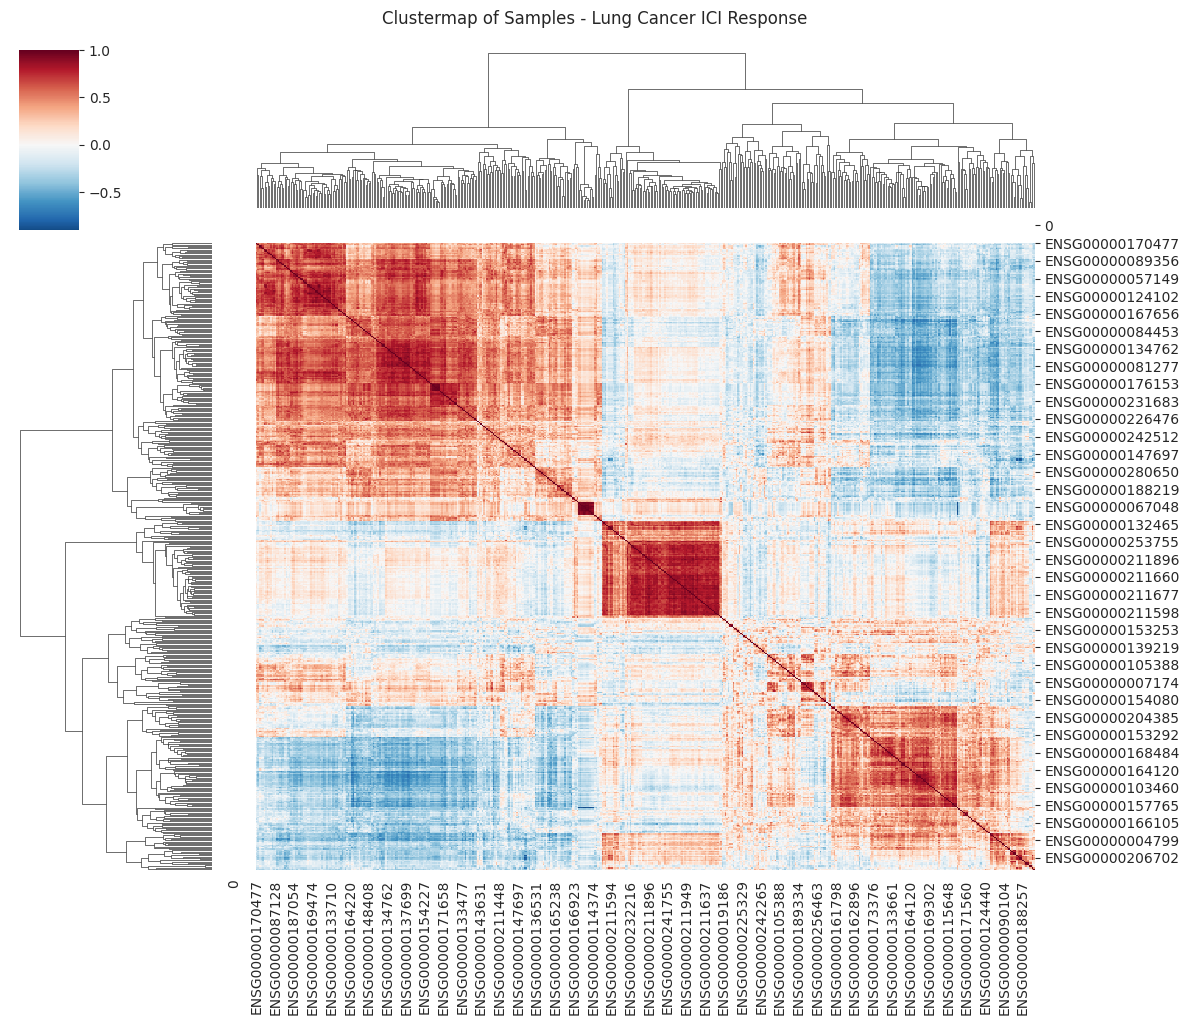

### 3. Дифференциальная экспрессия (DESeq2)

Для выявления генов, связанных с ответом на ICI-терапию, был проведён анализ дифференциальной экспрессии между группами responders (R) и non-responders (NR) с помощью DESeq2. Значимыми считались гены с padj < 0,05.

Всего обнаружено 55 статистически значимых генов.

| Направление | Количество генов |
|-------------|------------------|
| Повышены у R (log2FC > 0) | 10 |
| Повышены у NR (log2FC < 0) | 45 |

Преобладание генов с отрицательным log2FC указывает на то, что большая часть DEG имеет более высокую экспрессию у non-responders.

При ужесточении порога по абсолютному значению log2FC количество значимых генов практически не изменялось, что свидетельствует о выраженных различиях экспрессии для большинства найденных DEG.

| Порог | Количество генов |
|-------|------------------|
| \|log2FC\| > 1 | 55 |
| \|log2FC\| > 2 | 55 |
| \|log2FC\| > 3 | 48 |

Топ-10 наиболее значимых генов:

| Ген | log2FC | padj | Регуляция |
|-----|--------|------|------------|
| ENSG00000261642 | -22,73 | 5,56e-08 | Down in R |
| ENSG00000280059 | -22,78 | 5,56e-08 | Down in R |
| PRSS37 | -22,73 | 5,56e-08 | Down in R |
| ENSG00000259370 | -6,07 | 1,38e-05 | Down in R |
| CDSN | -5,62 | 1,20e-04 | Down in R |
| MT-RNR1 | -3,83 | 2,91e-04 | Down in R |
| ENSG00000245970 | -5,23 | 3,52e-04 | Down in R |
| MT-RNR2 | -3,77 | 7,34e-04 | Down in R |
| SPRR2G | -10,20 | 1,91e-03 | Down in R |
| WSCD2 | +3,26 | 1,91e-03 | Up in R |

Среди топ-10 значимых генов большинство имеют отрицательный log2FC, то есть повышенную экспрессию у NR. Это согласуется с результатами PCA и clustermap: несмотря на частичное перекрывание групп, между responders и non-responders присутствуют устойчивые различия в транскриптомных профилях.

### 4. Volcano plot

Для визуализации результатов дифференциальной экспрессии был построен volcano plot при пороге \|log2FC\| > 3. По оси X отложен log2FoldChange, по оси Y — -log10(padj).

При данном пороге значимыми оказались 29 генов. Большинство значимых генов расположены в левой части графика и имеют отрицательный log2FC, что соответствует их повышенной экспрессии у non-responders (NR). Гены с повышенной экспрессией у responders (R) представлены значительно меньшим числом.

Наиболее значимые гены с отрицательным log2FC включают ENSG00000259370, CDSN, MT-RNR1 и MT-RNR2. Среди генов, повышенных у responders, наиболее выраженным является WSCD2.

Полученные результаты согласуются с DESeq2-анализом и подтверждают, что различия между группами R и NR преимущественно связаны с генами, более активно экспрессирующимися у non-responders.

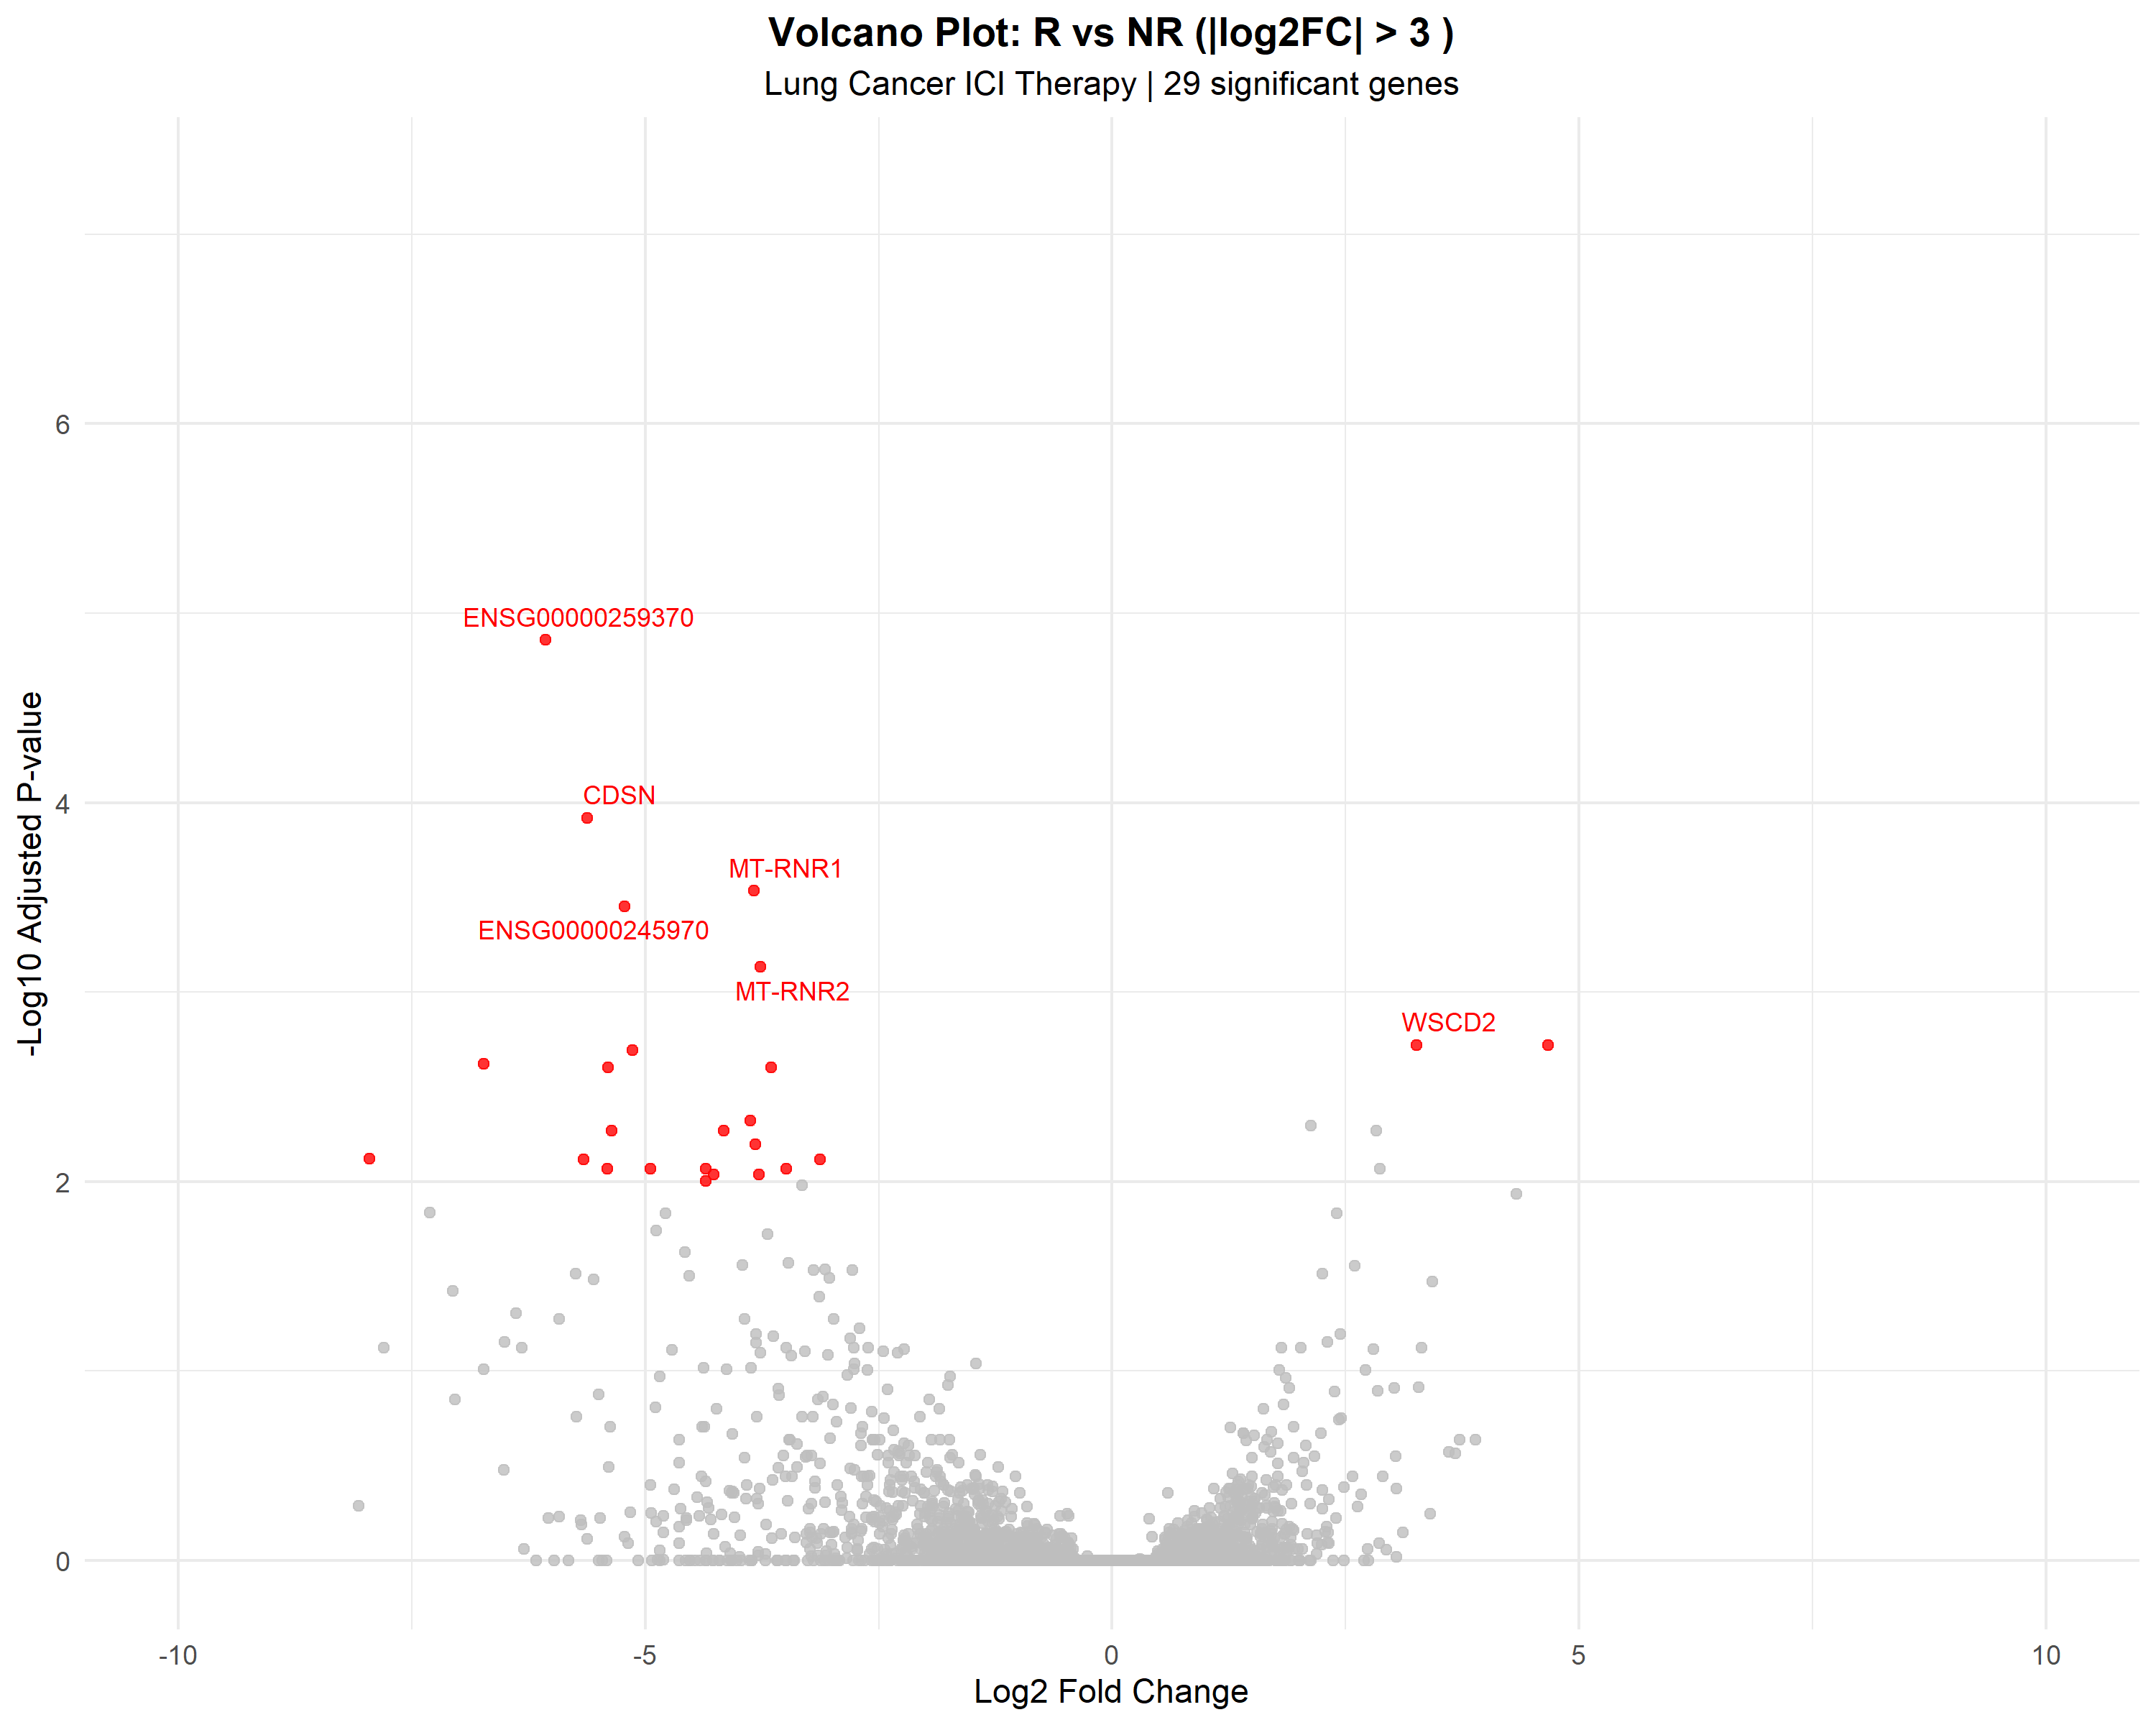

## Выводы

Анализ RNA-seq данных пациентов с раком лёгкого, получавших ICI-терапию, выявил различия в транскриптомных профилях между responders (R) и non-responders (NR). PCA и clustermap показали частичное разделение групп без полного формирования независимых кластеров, что отражает высокую биологическую гетерогенность опухолей. Были обнаружены три потенциальных выброса, которые были исключены из дальнейшего анализа. Явных признаков выраженного batch-effect выявлено не было.

DESeq2-анализ обнаружил 55 статистически значимых дифференциально экспрессированных генов (padj < 0,05), при этом большинство генов имели повышенную экспрессию у non-responders. Volcano plot подтвердил преобладание генов с отрицательным log2FC, а наиболее значимые изменения наблюдались для ENSG00000259370, CDSN, MT-RNR1 и MT-RNR2. Полученные результаты свидетельствуют о наличии устойчивых молекулярных различий между группами, связанных с ответом на ICI-терапию.

# Часть 2 - Анализ дифференциальной экспрессии (LIMMA)

## 0. Постановка задачи и характеристика данных

Во второй части используются микрочиповые данные GSE63885. Образцы получены от пациентов с раком яичников, платформа — Affymetrix U133 Plus 2.0. Данные предобработаны методом RMA, экспрессия представлена в виде логарифмических интенсивностей. Матрица содержит 7 588 генов и 41 образец.

Из метаданных выделены две группы в зависимости от ответа на химиотерапию: pCR (complete response) — 39 образцов, pNC (non-complete response) — 2 образца. Соотношение групп крайне несбалансированное.

Для анализа выбран LIMMA — стандартный метод для микрочиповых данных. Он основан на линейных моделях с эмпирической байесовской оценкой дисперсии, что позволяет стабильно оценивать изменения экспрессии при малом количестве образцов.

**Задачи анализа:**
- выявить гены, дифференциально экспрессированные между pCR и pNC (adj.P.Val < 0,05);
- оценить количество значимых генов при порогах |logFC| > 1, 2 и 3;
- выбрать оптимальный порог.

### Результаты LIMMA-анализа

LIMMA-анализ был проведён для сравнения групп pCR и pNC. Статистически значимых дифференциально экспрессированных генов при FDR < 0,05 обнаружено не было.

| Порог | Количество значимых генов (adj.P.Val < 0,05) |
|-------|---------------------------------------------|
| \|logFC\| > 1 | 0 |
| \|logFC\| > 2 | 0 |
| \|logFC\| > 3 | 0 |

Значения logFC находились в узком диапазоне, что указывает на отсутствие выраженных различий экспрессии между группами.

| Статистика logFC | Значение |
|------------------|----------|
| Минимум | -0,378 |
| Максимум | 0,442 |
| Медиана | 0,000 |

Топ-5 генов по номинальному p-value (без FDR-коррекции):

| Ген | logFC | P.Value |
|-----|-------|---------|
| ZSCAN18 | 0,738 | 8,14e-05 |
| MYOM1 | -1,075 | 9,33e-05 |
| CDC14B | -0,670 | 2,01e-04 |
| CTSC | -1,075 | 3,86e-04 |
| SUPT16H | -1,486 | 4,59e-04 |

Volcano plots для порогов |logFC| > 1, 2 и 3 также подтвердили отсутствие статистически значимых генов: ни одна точка не пересекала порог adj.P.Val < 0,05. При увеличении порога |logFC| число потенциальных кандидатов уменьшалось, однако после коррекции на множественное тестирование значимых генов не оставалось.

**Выбор порога LogFC**

Хотя FDR-значимых генов не обнаружено ни при одном пороге, при наличии значимых результатов оптимальным считается |logFC| > 2. Этот порог обеспечивает баланс между чувствительностью и специфичностью. В данном анализе выбор порога не влияет на итоговое заключение из-за отсутствия значимых генов.

Наиболее вероятная причина отсутствия значимых результатов — крайне малый размер группы pNC (n=2), из-за чего статистическая мощность анализа существенно снижена. В таких условиях даже гены с относительно низкими p-value не проходят FDR-коррекцию. Для получения более надёжных результатов требуется увеличение размера выборки, особенно для группы pNC.

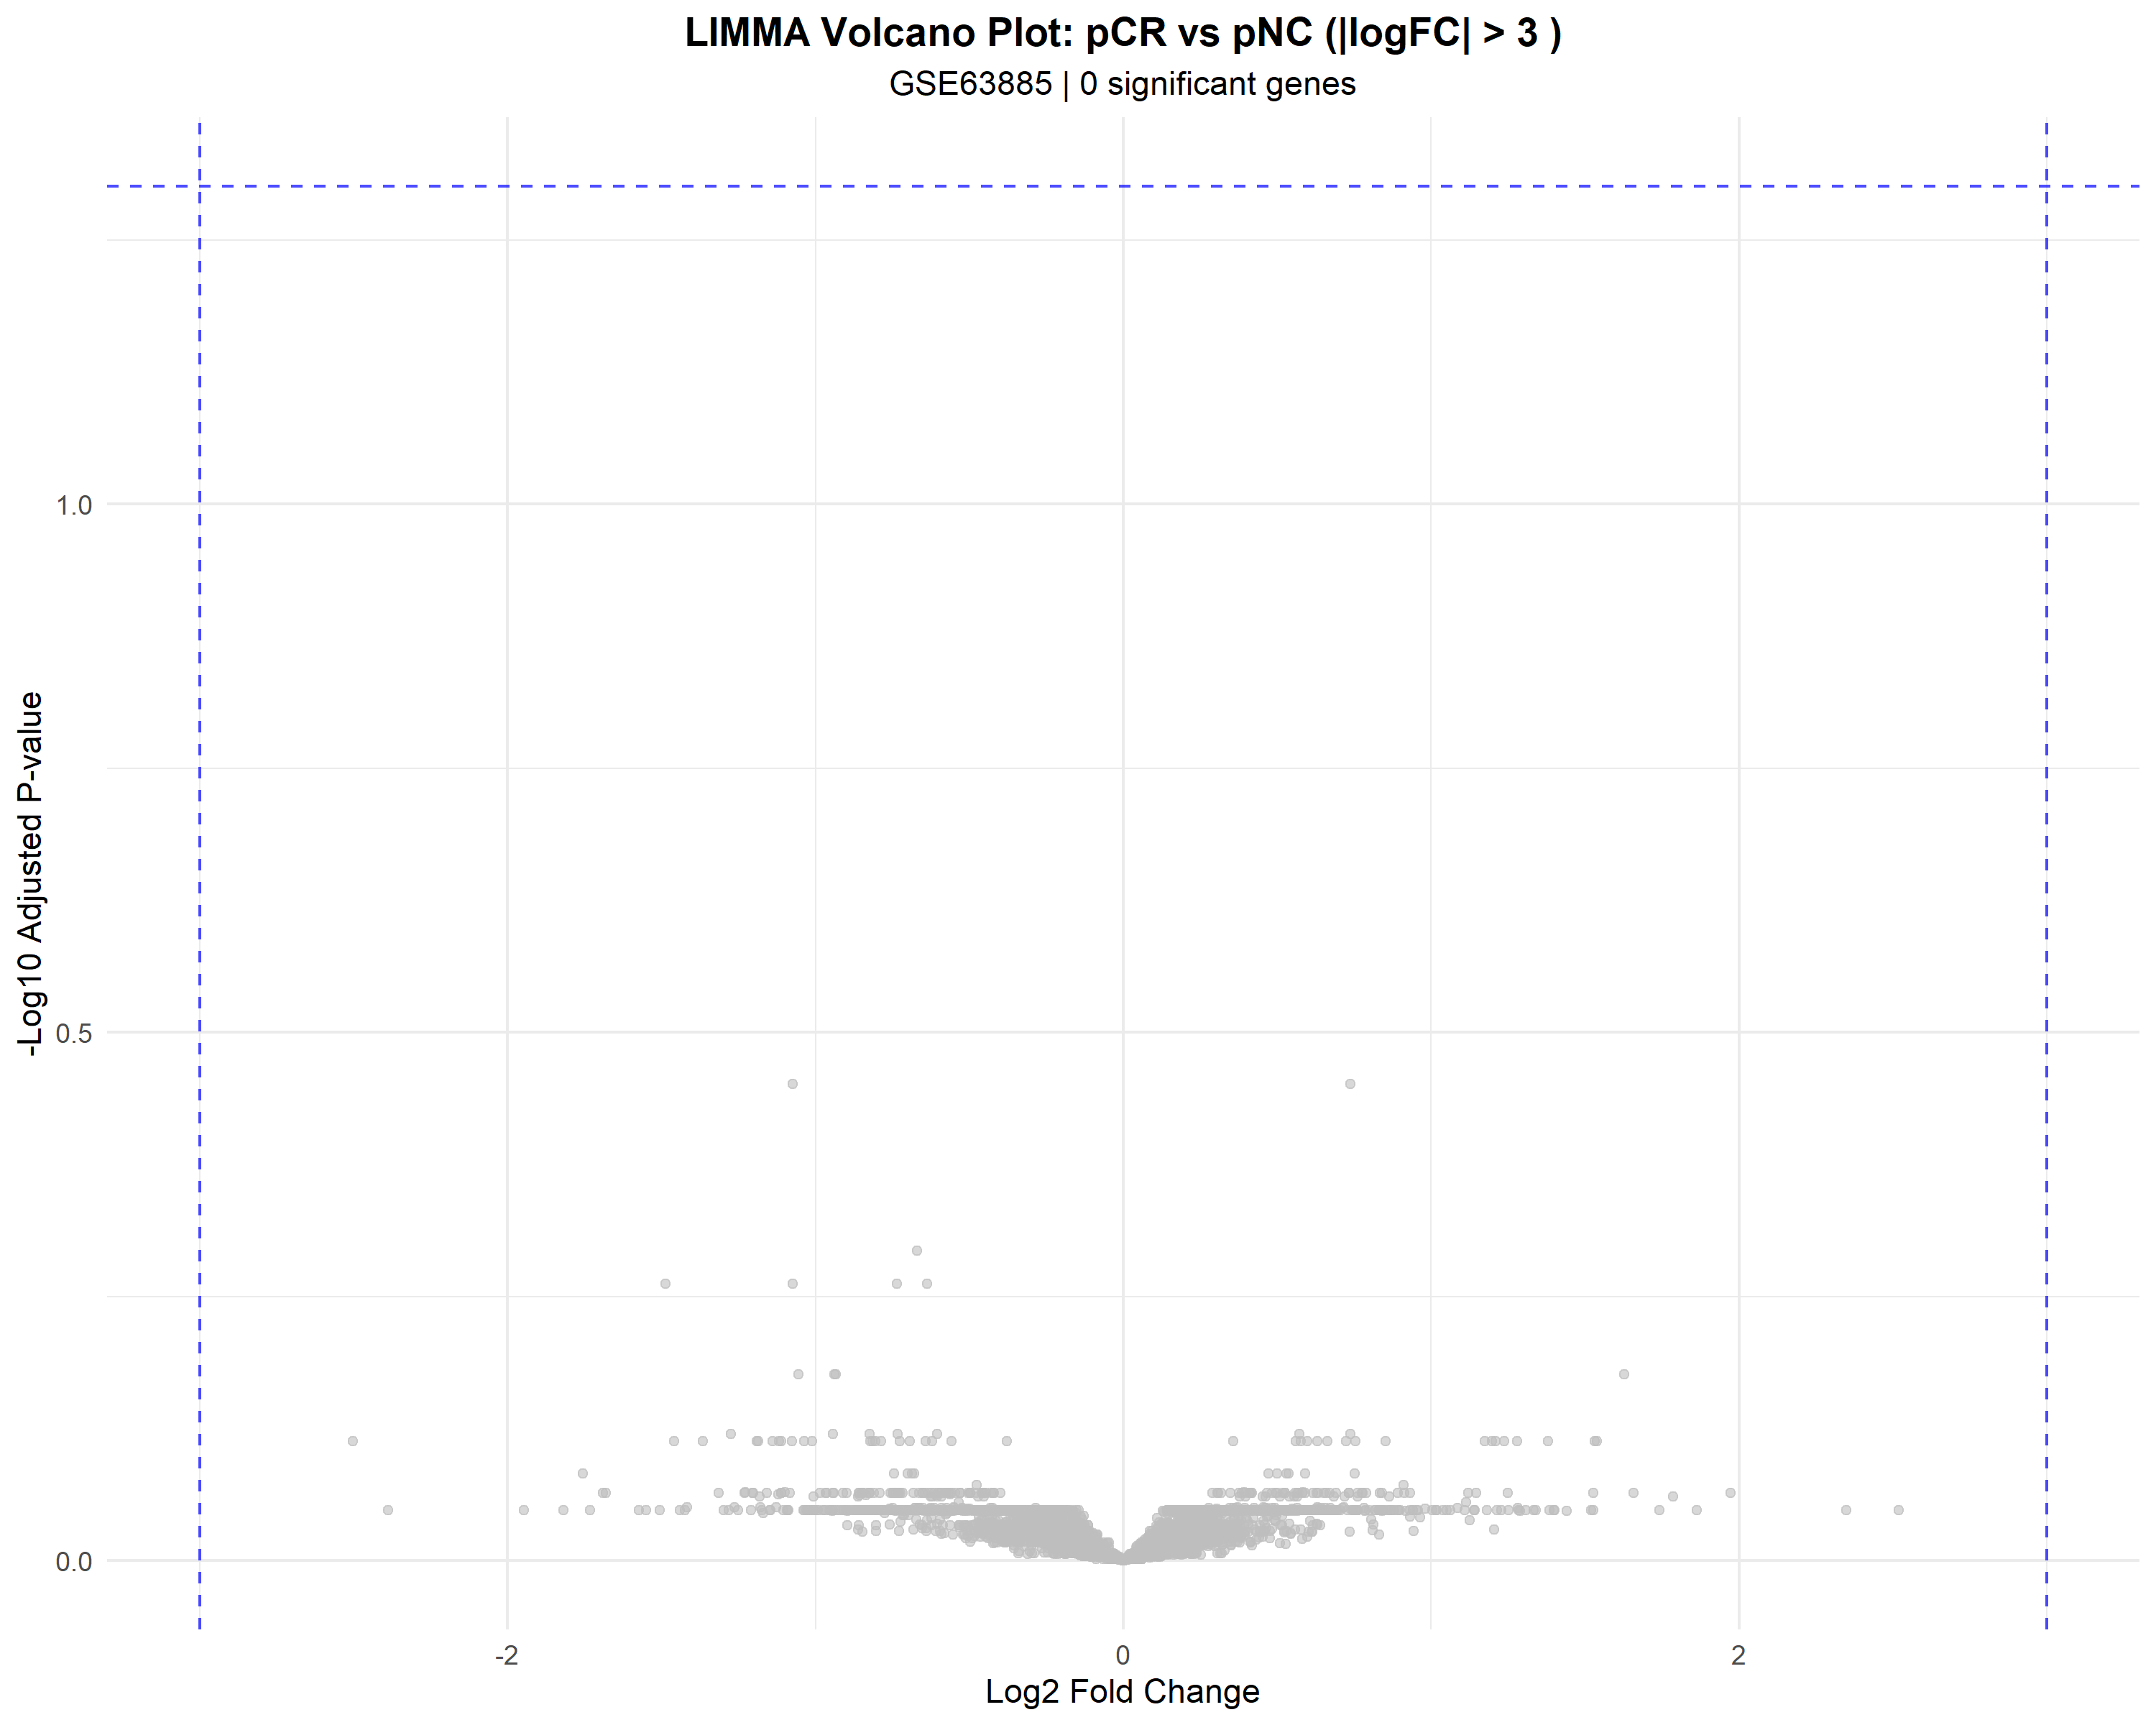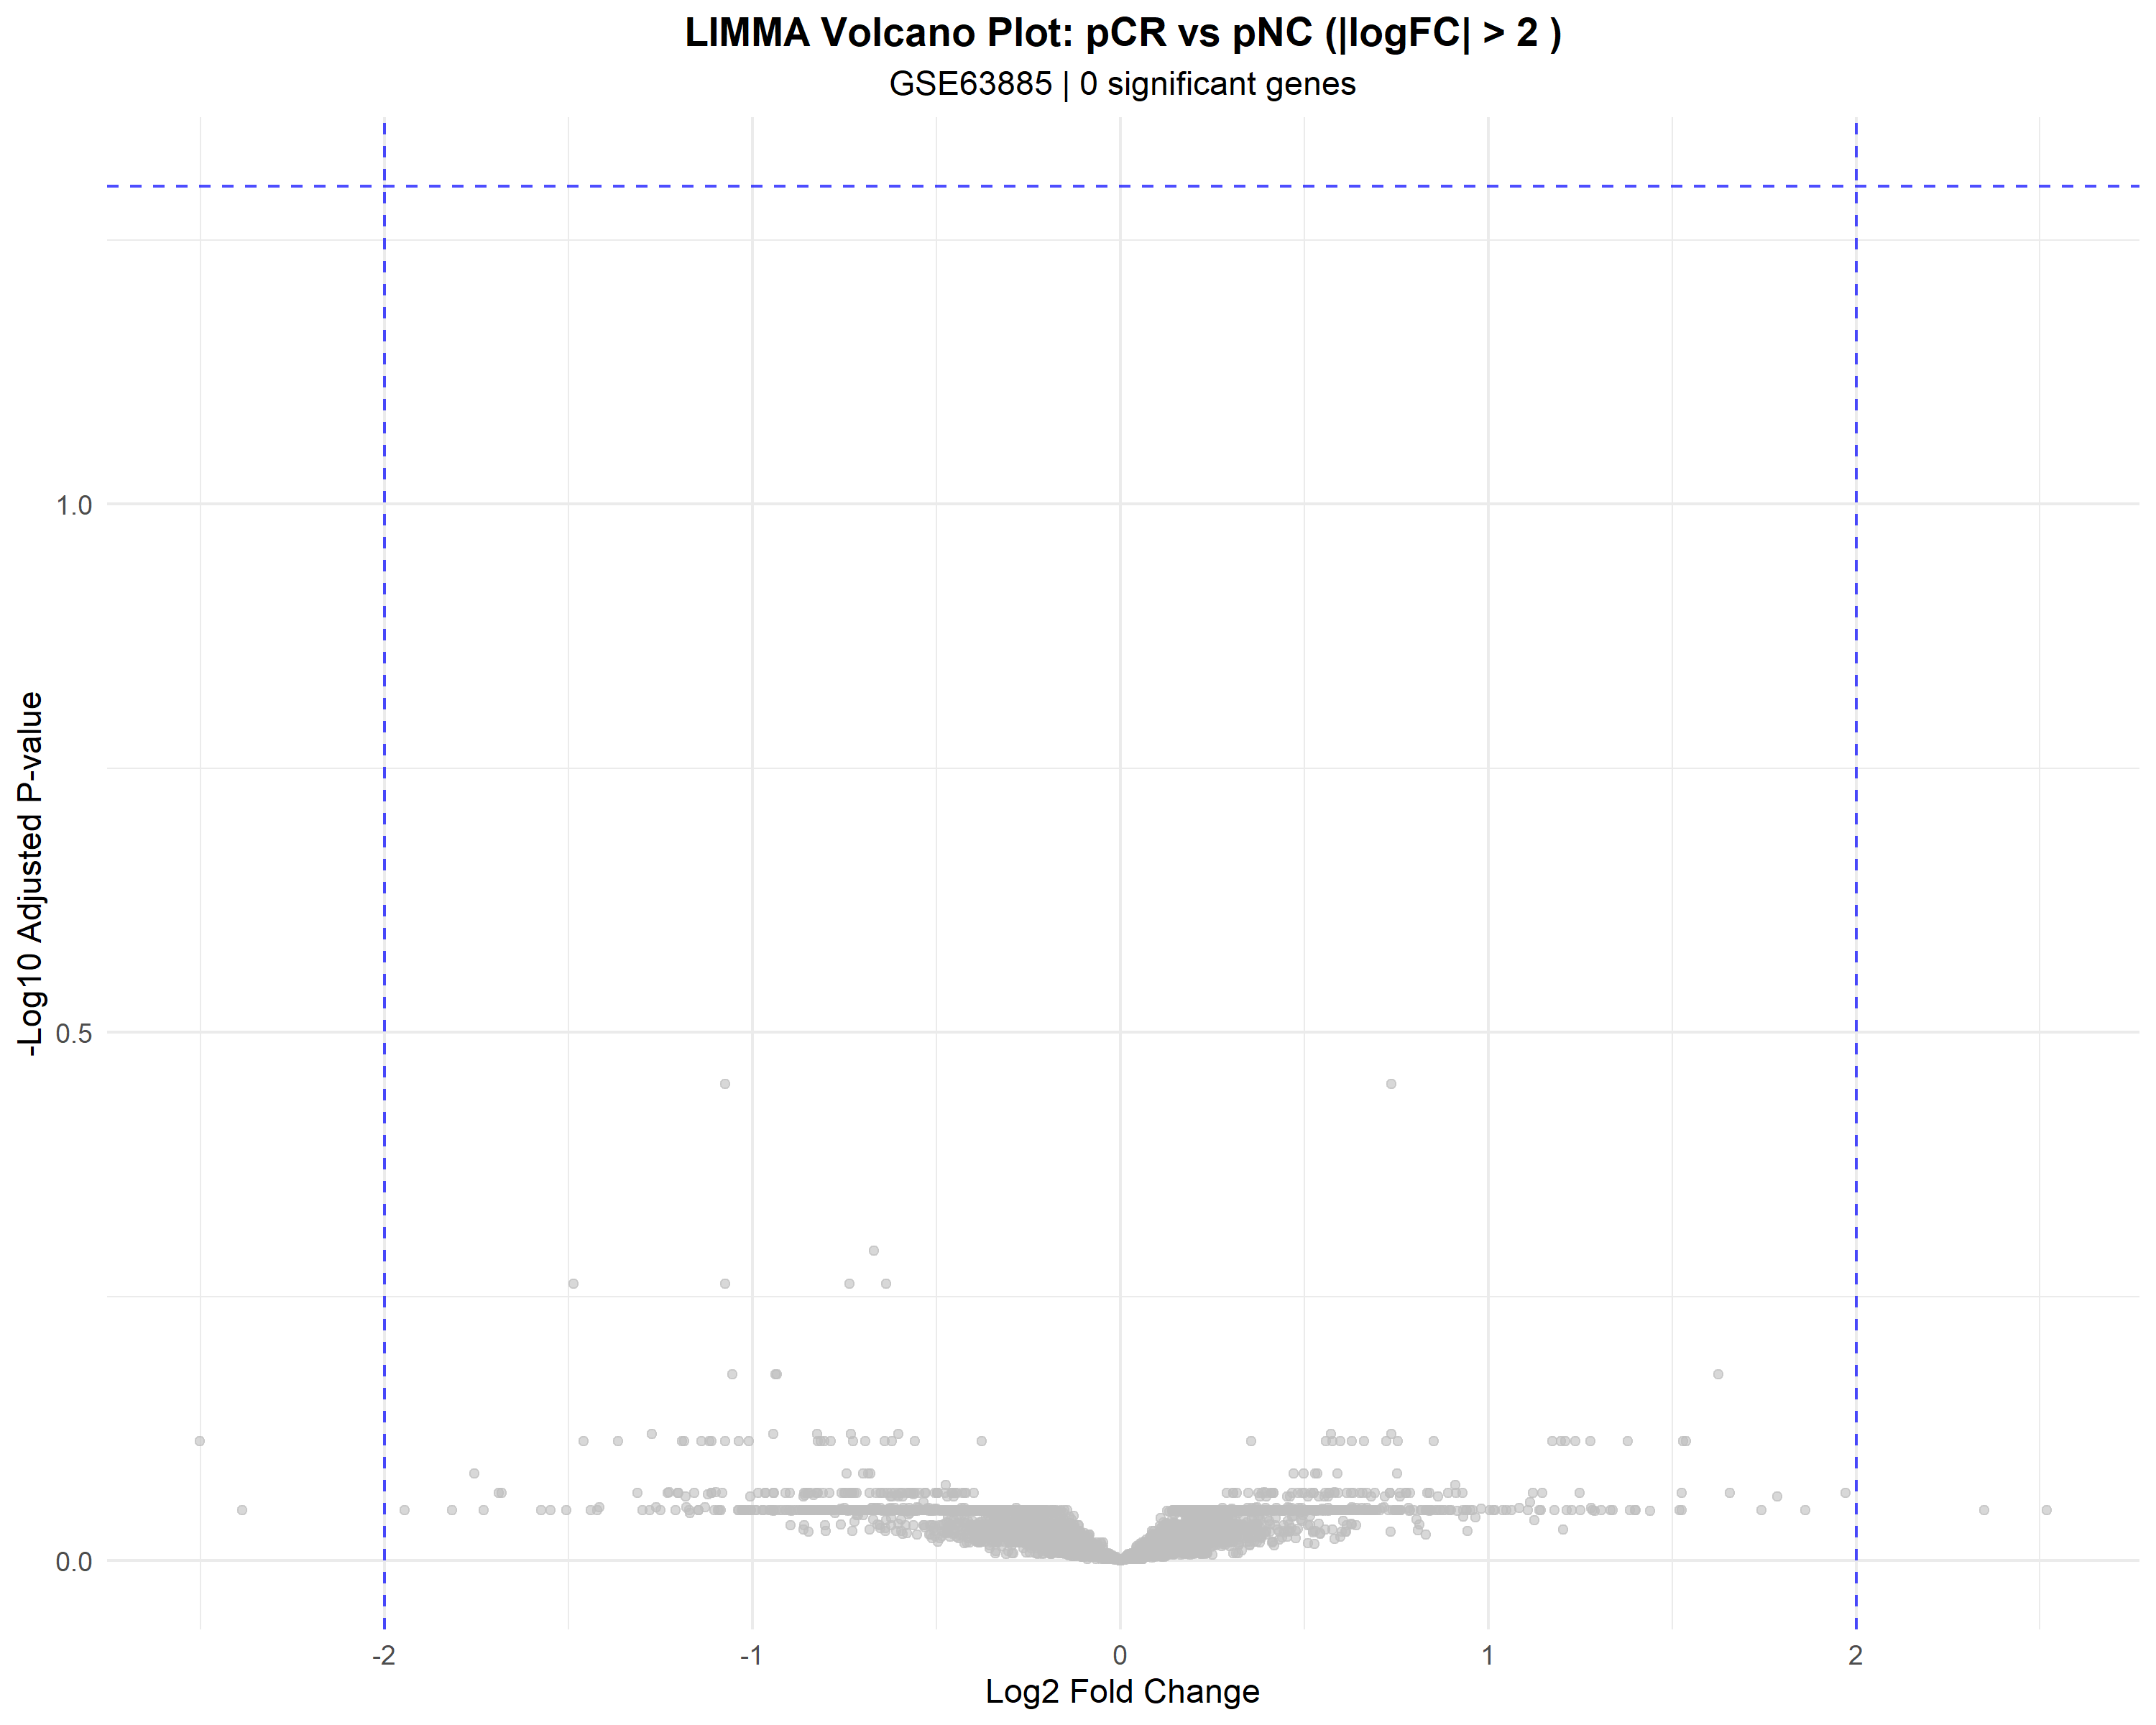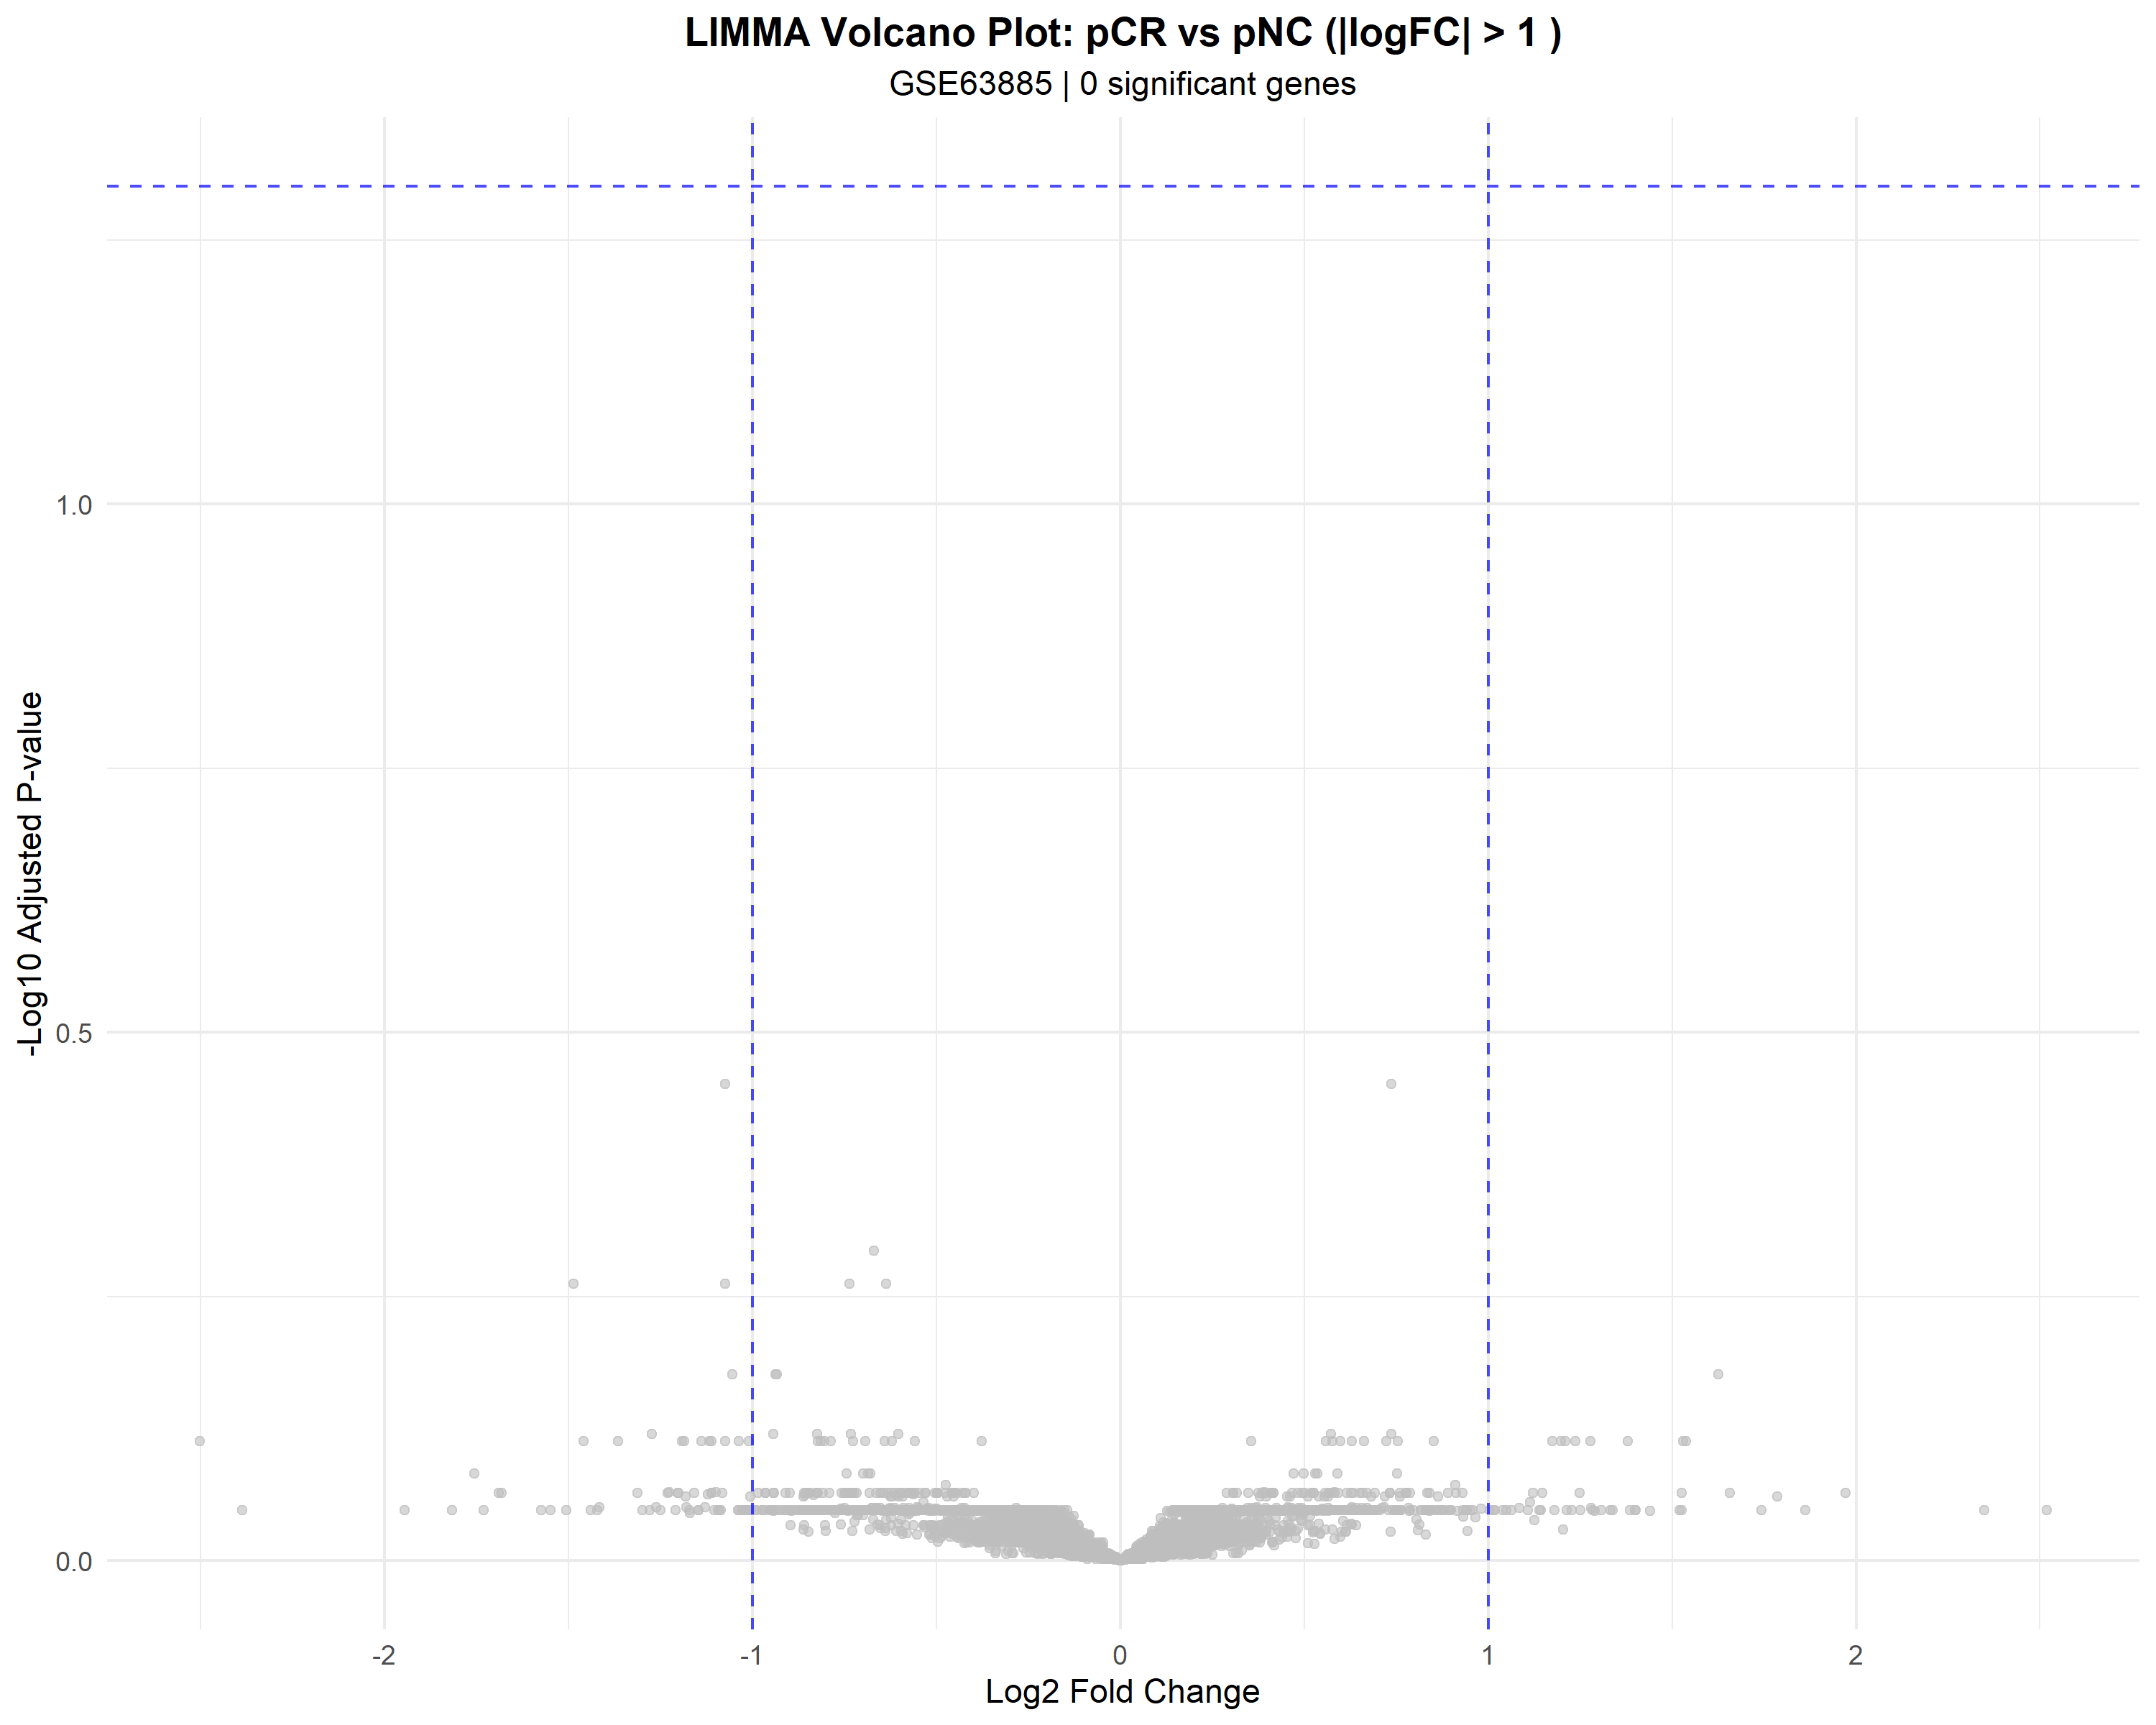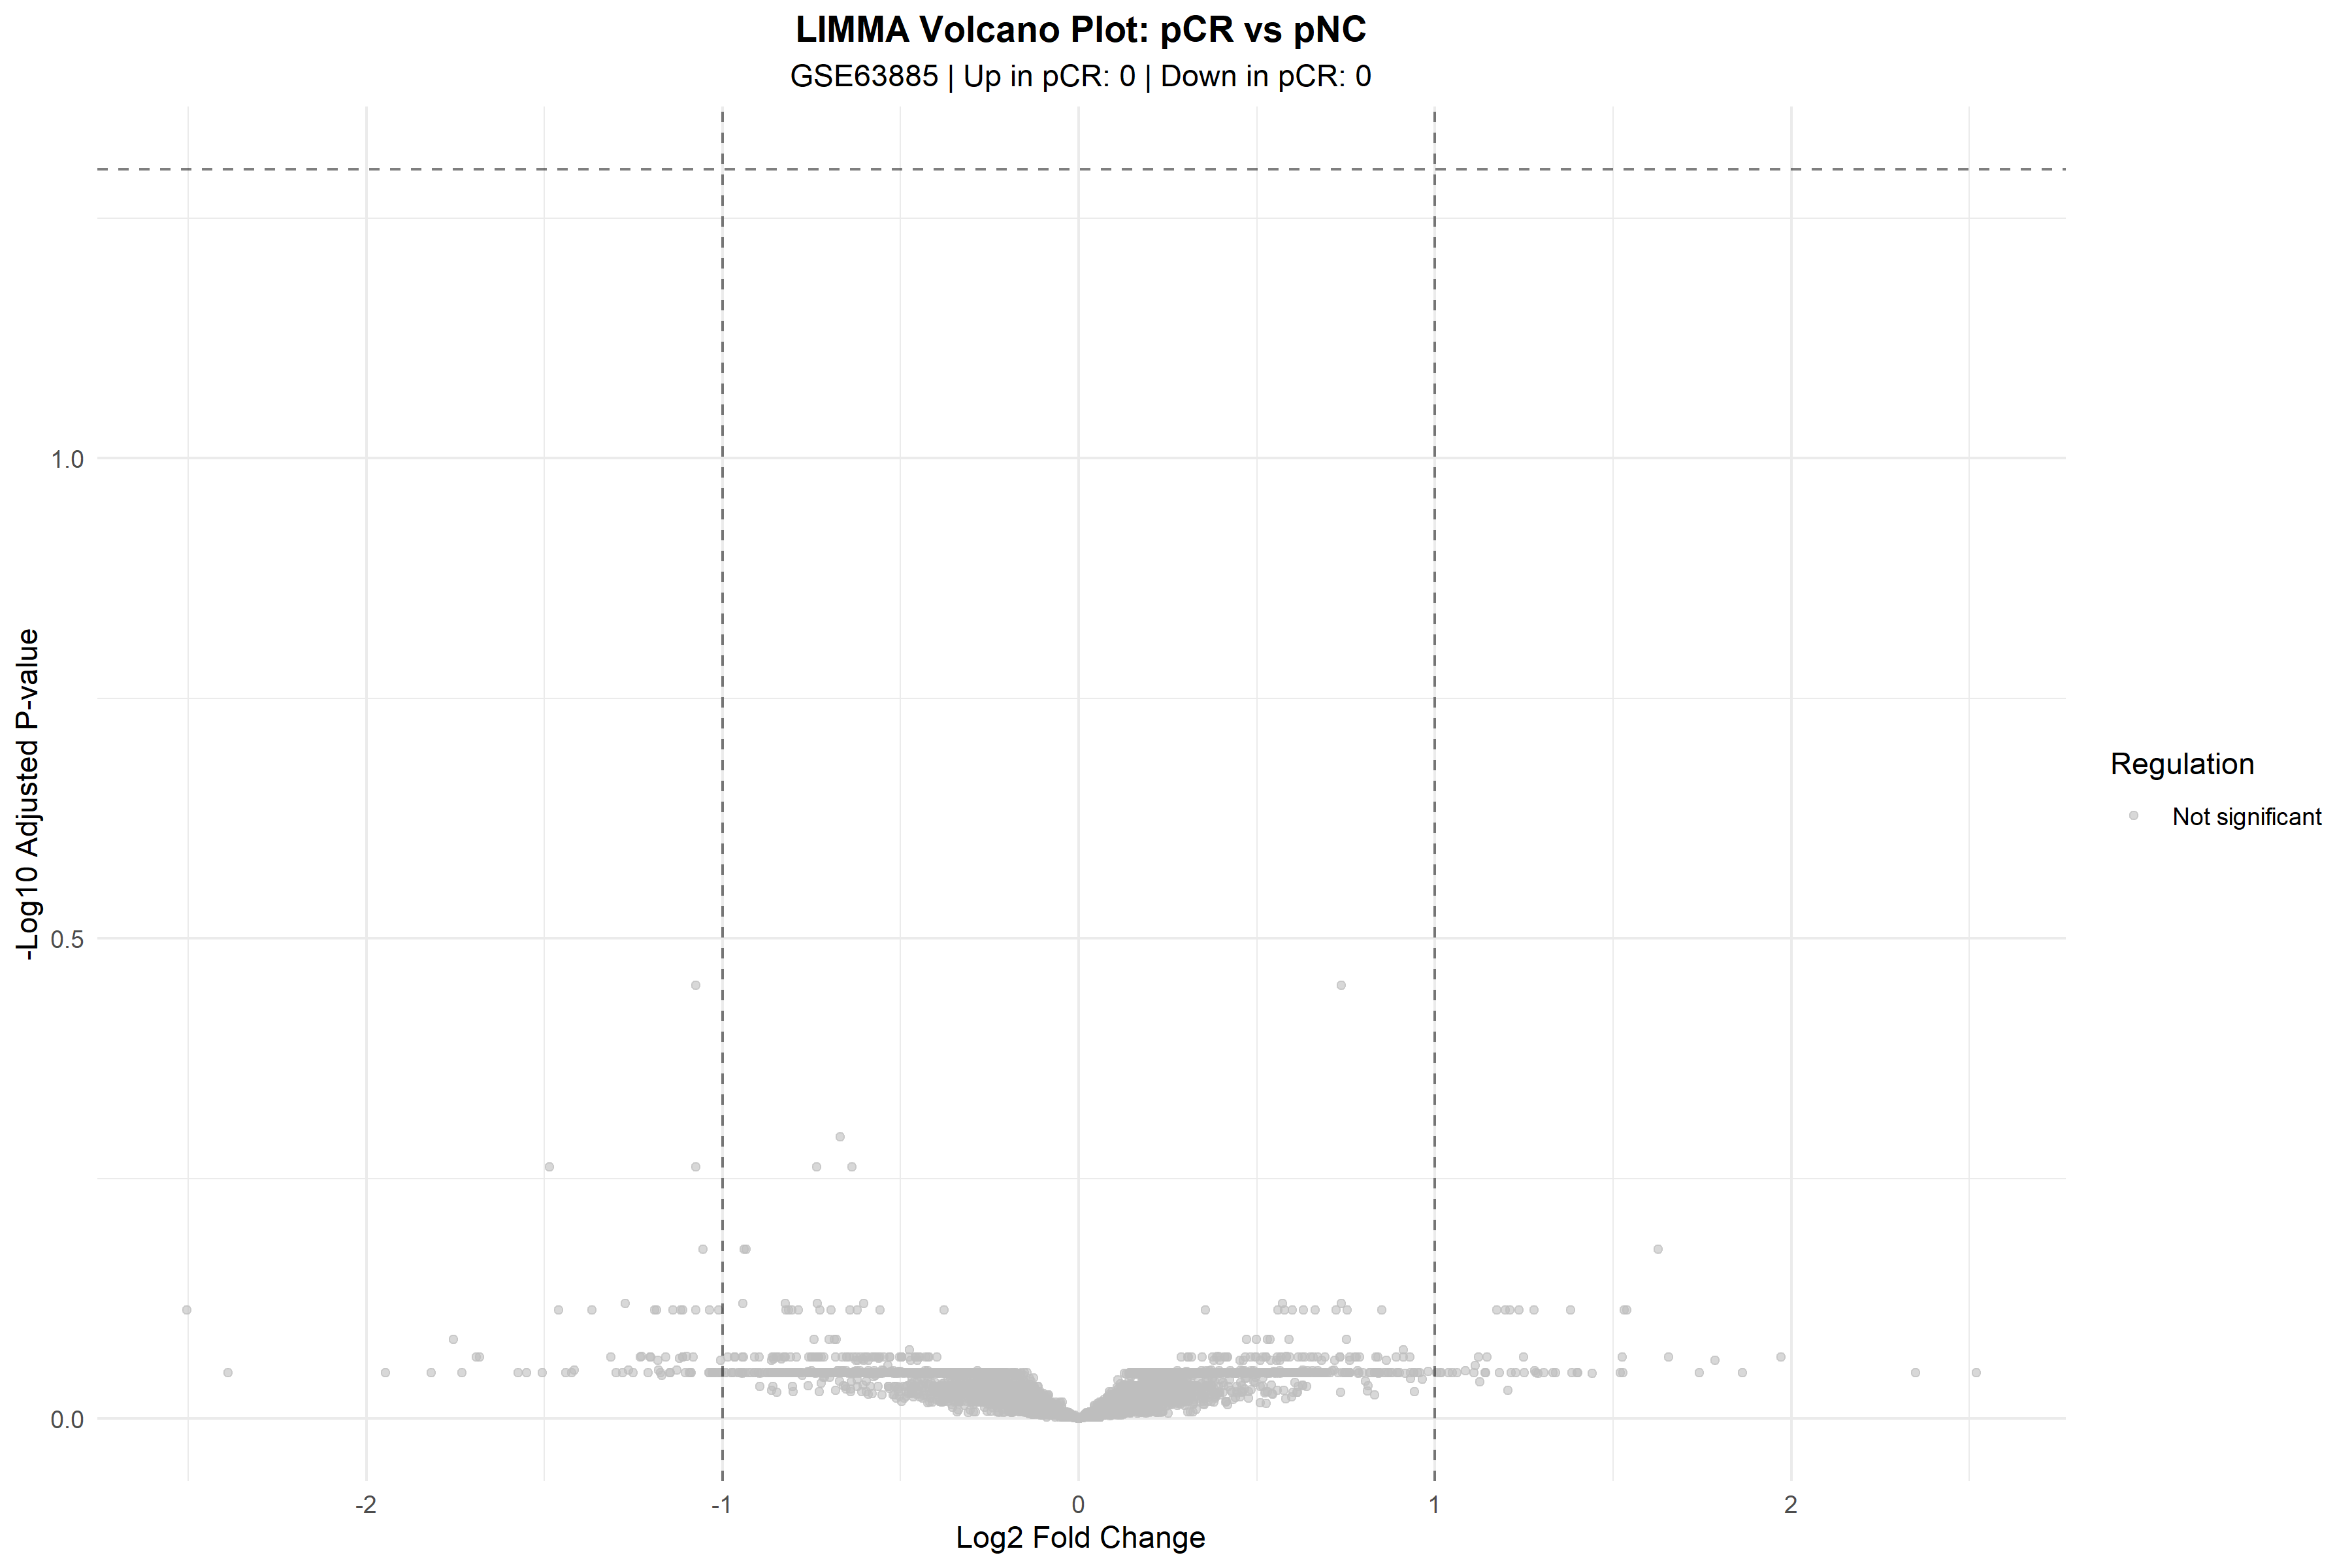

## Выводы

LIMMA-анализ не выявил статистически значимых дифференциально экспрессированных генов между группами pCR и pNC при FDR < 0,05. Значения logFC находились в узком диапазоне и были сосредоточены около нуля, что указывает на отсутствие выраженных различий экспрессии между группами. Volcano plots для различных порогов \|logFC\| также подтвердили отсутствие значимых результатов.

Основной причиной, вероятно, является крайне малый размер группы pNC (n=2), из-за чего статистическая мощность анализа недостаточна для надёжного выявления различий после коррекции на множественное тестирование. Для получения более достоверных результатов требуется увеличение размера выборки, особенно для группы pNC.